In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [16]:
df = pd.read_csv("../data/processed/marketing_campaign_cleaned.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,Complain,Response,Age,Children,Total_Spending,Customer_Tenure,Total_Purchases,Average_Spend_Per_Purchase,Cluster,Customer_Segment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,1,69,0,1617,5071,22,70.304348,3,Premium VIP Customers
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,72,2,27,4521,4,5.400000,0,Low-Value Customers
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,61,0,776,4720,20,36.952381,1,Loyal Customers
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,42,1,53,4547,6,7.571429,0,Low-Value Customers
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,45,1,422,4569,14,28.133333,2,Dormant Customers


In [3]:
print(df["Response"].value_counts())

Response
0    1906
1     334
Name: count, dtype: int64


In [4]:
features = [

    "Income",
    "Age",
    "Recency",

    "Kidhome",
    "Teenhome",

    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",

    "NumWebVisitsMonth",
    "NumDealsPurchases",

    "Total_Spending",
    "Total_Purchases"

]

X = df[features]

y = df["Response"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
importance = pd.DataFrame({
    "Feature":features,
    "Importance":rf.feature_importances_
})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
importance

,Feature,Importance
10,Total_Spending,0.176156
2,Recency,0.170977
0,Income,0.135163
6,NumCatalogPurchases,0.097908
8,NumWebVisitsMonth,0.085170
7,NumStorePurchases,0.071357
1,Age,0.070264
11,Total_Purchases,0.054483
5,NumWebPurchases,0.053575
9,NumDealsPurchases,0.039885


In [17]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            random_state=42
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=500,
            max_depth=10,
            min_samples_split=5,
            class_weight="balanced",
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=42
        )

}

In [18]:
results = []

best_model = None
best_auc = -1

for name, model in models.items():

    # Logistic Regression needs scaled features
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)
        prob = model.predict_proba(X_test_scaled)[:,1]

    else:
        model.fit(X_train, y_train)

        pred = model.predict(X_test)
        prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, pred)

    precision = precision_score(y_test, pred)

    recall = recall_score(y_test, pred)

    f1 = f1_score(y_test, pred)

    auc = roc_auc_score(y_test, prob)

    results.append({

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "ROC_AUC":auc

    })

    if auc > best_auc:
        best_auc = auc
        best_model = model

comparison = pd.DataFrame(results)

comparison.sort_values(
    by="ROC_AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Random Forest,0.830357,0.447059,0.567164,0.500000,0.851158
3,Gradient Boosting,0.868304,0.666667,0.238806,0.351648,0.849767
4,XGBoost,0.868304,0.617647,0.313433,0.415842,0.833608
0,Logistic Regression,0.861607,0.600000,0.223881,0.326087,0.813629
1,Decision Tree,0.830357,0.415094,0.328358,0.366667,0.636698


In [19]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    best_model,
    "../models/campaign_response_model.pkl"
)

print("✅ Best Campaign Response Model Saved")

✅ Best Campaign Response Model Saved


In [20]:
os.makedirs("../reports", exist_ok=True)

comparison.to_csv(
    "../reports/classification_model_comparison.csv",
    index=False
)

comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.861607,0.600000,0.223881,0.326087,0.813629
1,Decision Tree,0.830357,0.415094,0.328358,0.366667,0.636698
2,Random Forest,0.830357,0.447059,0.567164,0.500000,0.851158
3,Gradient Boosting,0.868304,0.666667,0.238806,0.351648,0.849767
4,XGBoost,0.868304,0.617647,0.313433,0.415842,0.833608


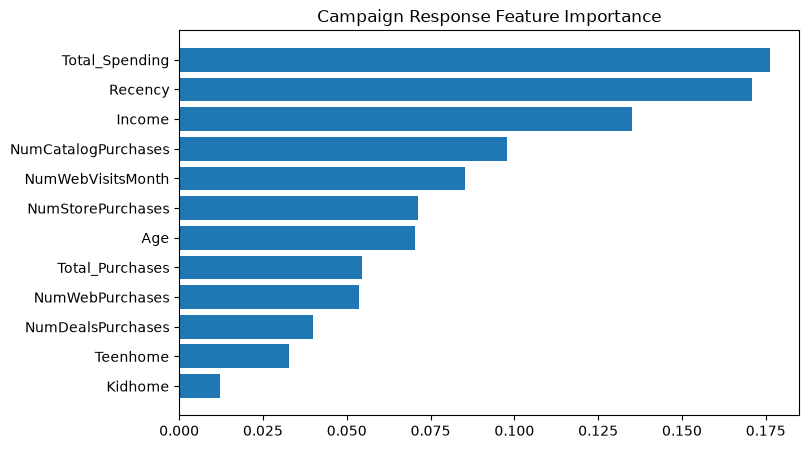

In [21]:
plt.figure(figsize=(8,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.gca().invert_yaxis()
plt.title("Campaign Response Feature Importance")
plt.show()

In [22]:
import joblib

joblib.dump(rf, "../models/campaign_response_model.pkl")

print("✅ Campaign Response model saved.")

✅ Campaign Response model saved.


In [23]:
df["Response_Probability"] = rf.predict_proba(X)[:, 1]

df[["Response", "Response_Probability"]].head()

,Response,Response_Probability
0,1,0.786332
1,0,0.148889
2,0,0.276894
3,0,0.067808
4,0,0.143420
